In [208]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as f
from  torchvision import transforms as t,datasets
from torch.utils.data import Dataset, DataLoader
import time
from tqdm import tqdm
d=torch.device("cpu")
import pandas as pd
import numpy as np

In [209]:
#data set;
data=torch.load("mathbert_embeddings.pt")
print(data.shape)

torch.Size([6525, 768])


In [210]:
import math
embeddings=data
pt=pd.read_csv("strings_infix_all_four.csv")
y=pt[[ "p_initial_residual"]].values
y_mean = y.mean(axis=0)
y_std = y.std(axis=0)
y=(y - y_mean) / y_std
# y_min= y.min(axis=0)
# y_max= y.max(axis=0)
# y_norm = (y-y_min)/(y_max - y_min)
y=torch.tensor(y,dtype=torch.float32)
print(y.shape)
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels
    def __len__(self):
        return len(self.embeddings)
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]
dataset = EmbeddingDataset(embeddings, y)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")


torch.Size([6525, 1])
Train size: 4567, Val size: 978, Test size: 980


In [211]:
print(y)

tensor([[-0.6240],
        [-0.6240],
        [ 0.1213],
        ...,
        [-0.6240],
        [-0.3087],
        [-0.5236]])


In [212]:
#hyperparameters
embeddings_size=768
num_heads=8
learning_rate=0.001
batch_size=64

In [213]:
# class self_att(nn.Module):
#     def __init__(self,embed_size=128,heads=12):
#         super(self_att,self).__init__()
#         self.embed_size=embed_size
#         self.head=heads
#         self.head_dim=embed_size//self.head
#         self.qvk=nn.Linear(embed_size,embed_size*3,bias=False)
#         self.fc_out=nn.Linear(embed_size,embed_size)
#     def forward(self,x):
#         B,L,_=x.shape
#         out=self.qvk(x)
#         chunks = torch.chunk(out, chunks=3, dim=-1)
#         q=chunks[0]
#         k=chunks[1]
#         v=chunks[2]
#         q = q.view(B, L, self.head, self.head_dim).transpose(1, 2)
#         k = k.view(B, L, self.head, self.head_dim).transpose(1, 2)
#         v = v.view(B, L, self.head, self.head_dim).transpose(1, 2)
#         scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
#         attn = torch.softmax(scores, dim=-1)
#         out = attn @ v
#         out = out.transpose(1, 2).contiguous().view(B, L, self.embed_size)
#         out=self.fc_out(out)
#         return out
class EquationEncoder(nn.Module):

    def __init__(self, embed_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, embed_size)
        )
    def forward(self, x):
        return self.net(x)
class encoder_block(nn.Module):
    def __init__(self,embedding,head):
        super().__init__()
        self.s_a=EquationEncoder(embedding)
        self.layer_norm=nn.LayerNorm(embedding)
        self.layer_norm2=nn.LayerNorm(embedding)
        self.layer_1=nn.Linear(embedding,embedding*2)
        self.layer_2=nn.Linear(embedding*2,embedding)
        self.dropout=nn.Dropout(0.3)
    def forward(self,x):
        out=self.s_a(x)
        out=out+x
        out=self.layer_norm(out)
        out_nn=self.layer_1(out)
        out_nn=self.dropout(out_nn)
        out_nn=nn.functional.relu(out_nn)
        out_nn=self.layer_2(out_nn)
        out_nn=self.dropout(out_nn)
        out=out+out_nn
        out=self.layer_norm2(out)
        return out
class encoder_layer(nn.Module):
    def __init__(self,embedding,head,layers):
        super().__init__()
        self.layers=nn.ModuleList([encoder_block(embedding,head) for _ in range(layers)])
    def forward(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    
class p_cf_simple(nn.Module):
    def __init__(self,embedding):
        super().__init__()
        self.wp_wcf=nn.Linear(embedding,4*embedding)
        self.layer_norm=nn.LayerNorm(embedding)
        self.layer_1_p=nn.Linear(embedding*2,embedding*4)
        self.layer_2_p=nn.Linear(embedding*4,embedding*2)
        self.layer_3_p=nn.Linear(embedding*2,embedding)
        self.layer_4_p=nn.Linear(embedding,1)
        # self.layer_1_c=nn.Linear(embedding*2,embedding*4)
        # self.layer_2_c=nn.Linear(embedding*4,embedding*2)
        # self.layer_3_c=nn.Linear(embedding*2,embedding)
        # self.layer_4_c=nn.Linear(embedding,1)
        self.dropout=nn.Dropout(0.3)
        self.embed_size=embedding
    def forward(self,x):
        out=self.wp_wcf(x)
        out_p=out[:,:self.embed_size*2]
        out_c=out[:,self.embed_size*2:]
        out_p_1=self.layer_1_p(out_p)
        out_p_1=self.dropout(out_p_1)
        out_p_1=nn.functional.relu(out_p_1)
        out_p_2=self.layer_2_p(out_p_1)
        out_p_2=self.dropout(out_p_2)
        out_p_2=nn.functional.relu(out_p_2)
        out_p_3=self.layer_3_p(out_p_2)
        out_p_3=self.dropout(out_p_3)
        out_p_3=nn.functional.relu(out_p_3)
        out_p_4=self.layer_4_p(out_p_3)
        # out_c=self.layer_1_c(out_c+out_p)
        # out_c=self.dropout(out_c)
        # out_c=nn.functional.relu(out_c)
        # out_c=self.layer_2_c(out_c+out_p_1)
        # out_c=self.dropout(out_c)
        # out_c=nn.functional.relu(out_c)
        # out_c=self.layer_3_c(out_c+out_p_2)
        # out_c=self.dropout(out_c)
        # out_c=nn.functional.relu(out_c)
        # out_c=self.layer_4_c(out_c+out_p_3)
        return out_p_4
class p_cf_add(nn.Module):
    def __init__(self,embedding,head):
        super().__init__()
        self.wp_wcf=nn.Linear(embedding,4*embedding)
        self.layer_norm=nn.LayerNorm(embedding)
        self.layer_1_p=nn.Linear(embedding*2,embedding*4)
        self.layer_2_p=nn.Linear(embedding*4,embedding*2)
        self.layer_3_p=nn.Linear(embedding*2,embedding)
        self.layer_4_p=nn.Linear(embedding,1)
        self.layer_1_c=nn.Linear(embedding*2,embedding*4)
        self.layer_2_c=nn.Linear(embedding*4,embedding*2)
        self.layer_3_c=nn.Linear(embedding*2,embedding)
        self.layer_4_c=nn.Linear(embedding,1)
        self.dropout=nn.Dropout(0.5)
        self.weight=torch.rand(3,2)
    def forward(self,x):
        m=nn.Softmax(dim=0)(self.weight)    
        out=self.wp_wcf(x)
        out_p=out[:,:self.embed_size*2]
        out_c=out[:,self.embed_size*2:]
        out_p_1=self.layer_1_p(out_p)
        out_p_1=self.dropout(out_p_1)
        out_p_1=nn.functional.relu(out_p_1)
        out_p_2=self.layer_2_p(out_p)
        out_p_2=self.dropout(out_p)
        out_p_2=nn.functional.relu(out_p)
        out_p_3=self.layer_3_p(out_p)
        out_p_3=self.dropout(out_p)
        out_p_3=nn.functional.relu(out_p)
        out_p=self.layer_4_p(out_p)
        out_c=self.layer_1_c(out_c+m[0]*out_p_1)
        out_c=self.dropout(out_c)
        out_c=nn.functional.relu(out_c)
        out_c=self.layer_2_c(out_c+m[1]*out_p_2)
        out_c=self.dropout(out_c)
        out_c=nn.functional.relu(out_c)
        out_c=self.layer_3_c(out_c+m[2]*out_p_3)
        out_c=self.dropout(out_c)
        out_c=nn.functional.relu(out_c)
        out_c=self.layer_4_c(out_c)
        return out_p,out_c


class final(nn.Module):
    def __init__(self,embedding,head,layers):
        super().__init__()
        self.encoder=encoder_layer(embedding,head,layers)
        self.p_cf=p_cf_simple(embedding)
    def forward(self,x):
        out=self.encoder(x)
        out_p=self.p_cf(out)
        return out_p
    

In [214]:
class nueral_net(nn.Module):
    def __init__(self,embedding):
        super().__init__()
        self.seq=nn.Sequential(
            nn.Linear(embedding,embedding*2),
            nn.ReLU(),
            nn.LayerNorm(embedding*2),
            nn.Linear(embedding*2,embedding*4),
            nn.ReLU(),
            nn.LayerNorm(embedding*4),
            nn.Linear(embedding*4,embedding*2),
            nn.ReLU(),
            nn.LayerNorm(embedding*2),
            nn.Linear(embedding*2,embedding),
            nn.ReLU(),
            nn.LayerNorm(embedding),
            nn.Linear(embedding,1)
        )
    def forward(self,x):
        out=self.seq(x)
        return out
mo=final(embeddings_size,num_heads,2).to(d)

In [215]:
criterion= torch.nn.HuberLoss()
optimizer=torch.optim.AdamW(mo.parameters(),lr=0.0001)
num_epochs=10
def loss(preds, labels):
    pred_classes = torch.argmax(preds, dim=1)
    true_classes = torch.argmax(labels, dim=1)
    loss=torch.mean((pred_classes - true_classes) ** 2)
    return loss

In [219]:
#training loop
losses=[]
for epoch in range(50):
    mo.train()
    total_loss = 0
    for batch_embeddings, batch_labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        batch_embeddings, batch_labels = batch_embeddings.to(d), batch_labels.to(d)
        optimizer.zero_grad()
        out_p= mo(batch_embeddings)
        loss_p = criterion(out_p.squeeze(), batch_labels[:, 0])
        total_batch_loss = loss_p
        total_batch_loss.backward()
        optimizer.step()
        total_loss += total_batch_loss.item()
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1/10: 100%|██████████| 72/72 [00:08<00:00,  8.87it/s]


Epoch 1, Loss: 0.3044


Epoch 2/10: 100%|██████████| 72/72 [00:08<00:00,  8.85it/s]


Epoch 2, Loss: 0.3040


Epoch 3/10: 100%|██████████| 72/72 [00:08<00:00,  8.98it/s]


...

Epoch 48, Loss: 0.2785


Epoch 49/10: 100%|██████████| 72/72 [00:07<00:00,  9.03it/s]


Epoch 49, Loss: 0.2761


Epoch 50/10: 100%|██████████| 72/72 [00:07<00:00,  9.27it/s]

Epoch 50, Loss: 0.2803


In [218]:
mo.eval()
with torch.no_grad():
    loss=[]
    loss_p=[]
    loss_c=[]
    i=0
    for batch_embeddings, batch_labels in tqdm(test_loader, desc=f"Epoch {10}/{10}"):
        batch_embeddings, batch_labels = batch_embeddings.to(d), batch_labels.to(d)
        out_p= mo(batch_embeddings)*y_std + y_mean
        batch_labels=batch_labels*y_std + y_mean
        loss_p.append(criterion(out_p.squeeze(), batch_labels[:, 0]).item())
        print(f"predicted-->{out_p.squeeze().cpu().numpy()} | actual--> {batch_labels[:, 0].cpu().numpy()}")
        
    print(f"Test Loss p: {sum(loss_p)/len(loss_p):.4f}, Test Loss c: {sum(loss_c)/len(loss_c):.4f}")



Epoch 10/10:   0%|          | 0/980 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_3188\348114627.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  out_p= mo(batch_embeddings)*y_std + y_mean
C:\Users\asus\AppData\Local\Temp\ipykernel_3188\348114627.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch_labels=batch_labels*y_std + y_mean
e:\transformers\venv\Lib\site-packages\torch\nn\modules\loss.py:1102: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
Epoch 10/10:   3%|▎         | 29/980 [00:00<00:06, 142.75it/s]

predicted-->0.061914103843877036 | actual--> [2.20494419e-07]
predicted-->0.03530183139589431 | actual--> [4.13087436e-09]
predicted-->0.03581524586010798 | actual--> [0.00022397]
predicted-->0.03499488725326161 | actual--> [0.0737682]
predicted-->0.07495702840670021 | actual--> [0.00554266]
predicted-->0.03656762845031063 | actual--> [4.13087436e-09]
predicted-->0.09471265087442751 | actual--> [0.0518323]
predicted-->0.13815080219096487 | actual--> [0.00034931]
predicted-->0.11331624454988852 | actual--> [0.50127998]
predicted-->0.11847854932994781 | actual--> [4.13087436e-09]
predicted-->0.12944198425709208 | actual--> [0.81073199]
predicted-->0.11986694473012957 | actual--> [0.0532942]
predicted-->0.021771553357811835 | actual--> [0.0008619]
predicted-->0.022621932406479875 | actual--> [0.00367244]
predicted-->0.10998128490868335 | actual--> [0.0541872]
predicted-->0.02040060902977911 | actual--> [2.12449361e-06]
predicted-->0.07862764405549959 | actual--> [0.0482053]
predicted-->0.

Epoch 10/10:   6%|▌         | 59/980 [00:00<00:06, 143.23it/s]

predicted-->0.10823584233028627 | actual--> [0.0185692]
predicted-->0.12188995469088307 | actual--> [0.0217416]
predicted-->0.13861591078928875 | actual--> [0.193057]
predicted-->0.0872379962924695 | actual--> [0.10101]
predicted-->0.014859452105604229 | actual--> [4.13087436e-09]
predicted-->0.07679181290177625 | actual--> [0.0549865]
predicted-->0.13636608422012328 | actual--> [0.163386]
predicted-->0.06257317965544482 | actual--> [0.0280278]
predicted-->0.06823144875725584 | actual--> [4.13087436e-09]
predicted-->0.09830110787623066 | actual--> [0.0792588]
predicted-->0.05451604466127318 | actual--> [4.13087436e-09]
predicted-->0.1409676986788755 | actual--> [0.132938]
predicted-->0.085665163140914 | actual--> [0.0723911]
predicted-->0.0605570121917912 | actual--> [0.23998]
predicted-->0.11536159413114523 | actual--> [4.13087436e-09]
predicted-->0.024124544769615786 | actual--> [0.0268309]
predicted-->0.06460829515652207 | actual--> [0.148337]
predicted-->0.15126566492784335 | actua

Epoch 10/10:   8%|▊         | 74/980 [00:00<00:06, 131.69it/s]

...

Epoch 10/10:  98%|█████████▊| 957/980 [00:06<00:00, 143.78it/s]

predicted-->0.13914143890745911 | actual--> [0.45223601]
predicted-->0.11215119582777125 | actual--> [0.0700481]
predicted-->0.07468177340972734 | actual--> [0.0294563]
predicted-->0.09915993997813415 | actual--> [0.0151499]
predicted-->0.03840315939961575 | actual--> [0.00196386]
predicted-->0.05850987228671944 | actual--> [0.00171864]
predicted-->0.16242624287938548 | actual--> [0.207802]
predicted-->0.1169168041339201 | actual--> [0.237794]
predicted-->0.12221457979193101 | actual--> [0.00344002]
predicted-->0.039994507861505574 | actual--> [0.0876779]
predicted-->0.05183014548147726 | actual--> [0.0287523]
predicted-->0.0731690298236127 | actual--> [0.42220899]
predicted-->0.01997501111925455 | actual--> [0.288392]
predicted-->0.041566789286022185 | actual--> [4.13087436e-09]
predicted-->0.04567784267996554 | actual--> [4.13087436e-09]
predicted-->0.12977886500067287 | actual--> [0.73437401]
predicted-->0.11251132618649798 | actual--> [0.0408827]
predicted-->0.017055066084110684 | 

Epoch 10/10: 100%|██████████| 980/980 [00:06<00:00, 144.63it/s]

predicted-->0.13571261357663436 | actual--> [0.0705806]
predicted-->0.030405643380175332 | actual--> [0.00189873]
predicted-->0.1017716913711749 | actual--> [0.0326384]
predicted-->0.02857463442895361 | actual--> [0.0520279]
predicted-->0.08942842295499273 | actual--> [0.0895572]
predicted-->0.13525273151018619 | actual--> [4.13087436e-09]
predicted-->0.019784135200155012 | actual--> [4.13087436e-09]
predicted-->0.13217511424641523 | actual--> [0.57994799]


ZeroDivisionError: division by zero

In [239]:
model=nueral_net(embeddings_size)
criterion=loss = nn.HuberLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,   # reduce every 10 epochs
    gamma=0.1       # multiply LR by 0.1
)
num_epochs=50
def loss(preds, labels):
    pred_classes = torch.argmax(preds, dim=1)
    true_classes = torch.argmax(labels, dim=1)
    loss=torch.mean((pred_classes - true_classes) ** 2)
    return loss

In [240]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_embeddings, batch_labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        batch_embeddings, batch_labels = batch_embeddings.to(d), batch_labels.to(d)
        optimizer.zero_grad()
        out_p= model(batch_embeddings)
        loss_p = criterion(out_p.squeeze(), batch_labels[:, 0])
        total_batch_loss = loss_p
        total_batch_loss.backward()
        optimizer.step()
        total_loss += total_batch_loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1/50: 100%|██████████| 72/72 [00:05<00:00, 14.19it/s]


Epoch 1, Loss: 0.5399


Epoch 2/50: 100%|██████████| 72/72 [00:04<00:00, 14.63it/s]


Epoch 2, Loss: 0.3407


Epoch 3/50: 100%|██████████| 72/72 [00:05<00:00, 14.30it/s]


...

Epoch 48, Loss: 0.2954


Epoch 49/50: 100%|██████████| 72/72 [00:05<00:00, 14.28it/s]


Epoch 49, Loss: 0.2895


Epoch 50/50: 100%|██████████| 72/72 [00:04<00:00, 14.55it/s]

Epoch 50, Loss: 0.2872


In [248]:
i=0

In [249]:
torch.save(model.state_dict(), "model.pth")
model.eval()
actuals=[]
preds=[]
with torch.no_grad():
    loss=[]
    loss_p=[]
    loss_c=[]
    for batch_embeddings, batch_labels in tqdm(test_loader, desc=f"Epoch {10}/{10}"):
        batch_embeddings, batch_labels = batch_embeddings.to(d), batch_labels.to(d)
        out_p = model(batch_embeddings)
        loss_p.append(criterion(out_p.squeeze(), batch_labels[:, 0]).item())
        actuals.append(batch_labels[:, 0].cpu().numpy())
        preds.append(out_p.squeeze().cpu().numpy())
        print(f"predicted-->{(out_p.squeeze().cpu().numpy())} | actual--> {batch_labels[:, 0].cpu().numpy()}")
        i=i+1
        if i==50:
            break
    print(f"Test Loss p: {sum(loss_p)/len(loss_p):.4f}")


Epoch 10/10:   0%|          | 0/980 [00:00<?, ?it/s]e:\transformers\venv\Lib\site-packages\torch\nn\modules\loss.py:1102: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
Epoch 10/10:   3%|▎         | 26/980 [00:00<00:03, 256.90it/s]

predicted-->-0.5007015466690063 | actual--> [-0.6240339]
predicted-->-0.50221848487854 | actual--> [-0.6240351]
predicted-->-0.4992585778236389 | actual--> [-0.6228011]
predicted-->-0.5144931077957153 | actual--> [-0.2175963]
predicted-->-0.3736023008823395 | actual--> [-0.59349686]
predicted-->-0.4477050006389618 | actual--> [-0.6240351]
predicted-->-0.2714332342147827 | actual--> [-0.338456]
predicted-->0.11895838379859924 | actual--> [-0.62211055]
predicted-->-0.17522740364074707 | actual--> [2.1378548]
predicted-->-0.31480884552001953 | actual--> [-0.6240351]
predicted-->0.09577953815460205 | actual--> [3.842835]
predicted-->-0.22909678518772125 | actual--> [-0.3304014]
predicted-->-0.5211551785469055 | actual--> [-0.61928636]
predicted-->-0.4996780753135681 | actual--> [-0.6038012]
predicted-->-0.29945001006126404 | actual--> [-0.32548127]
predicted-->-0.5258241891860962 | actual--> [-0.62402344]
predicted-->-0.27455613017082214 | actual--> [-0.3584396]
predicted-->-0.060296077281

Epoch 10/10:   5%|▌         | 49/980 [00:00<00:03, 262.55it/s]

Test Loss p: 0.1977


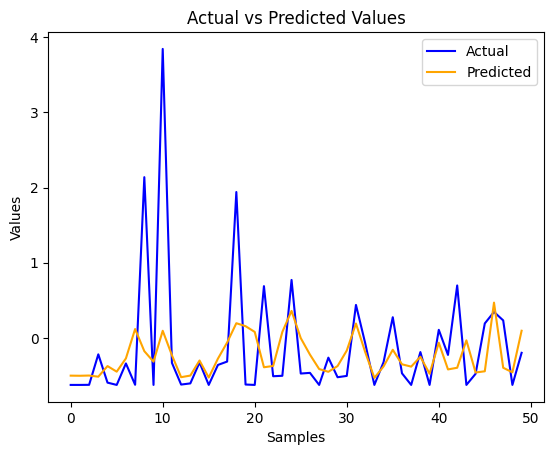

In [250]:
import matplotlib.pyplot as plt
plt.plot(actuals, label="Actual",color='blue')
plt.plot(preds, label="Predicted",color='orange')
plt.xlabel("Samples")
plt.ylabel("Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

In [ ]:
for i in range(len(actuals)):
    